<a href="https://colab.research.google.com/github/kayorde25/Flight-Price-Prediction/blob/main/notebooks_01_eda_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TripSmooth Flight Price Prediction

This notebook builds a machine learning pipeline to predict flight ticket prices using the Kaggle Flight Price Prediction dataset.

## Objectives
- load and inspect the dataset
- clean and preprocess the data
- build a Random Forest baseline
- build and tune an XGBoost model
- compare model performance
- export charts for GitHub
- generate business insights for TripSmooth

In [13]:
# Mount drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [14]:
from google.colab import files

# Upload files
uploaded = files.upload()

KeyboardInterrupt: 

In [15]:
# -----------------------------------------------------------
# IMPORT LIBRARIES
# -----------------------------------------------------------

# Work with file paths
from pathlib import Path

# Data handling
import pandas as pd
import numpy as np

# Plotting
import matplotlib.pyplot as plt

# Scikit-learn tools
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# XGBoost model
from xgboost import XGBRegressor

## Inspect columns across datasets

Before combining the datasets, we need to:
- check the structure of each dataset
- compare column names
- identify schema differences

This helps avoid errors when merging or concatenating data.

In [19]:
import pandas as pd

# Load datasets from the Google Drive path
business_df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/business.csv")
economy_df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/economy.csv")
clean_df = pd.read_csv("/content/drive/MyDrive/clean_dataset.csv")

# Print shapes
print("Business shape:", business_df.shape)
print("Economy shape:", economy_df.shape)
print("Clean shape:", clean_df.shape)

Business shape: (93487, 11)
Economy shape: (206774, 11)
Clean shape: (300153, 12)


In [20]:
# -----------------------------------------------------------
# DISPLAY COLUMN NAMES
# -----------------------------------------------------------

print("\nBusiness columns:")
print(business_df.columns.tolist())

print("\nEconomy columns:")
print(economy_df.columns.tolist())

print("\nClean dataset columns:")
print(clean_df.columns.tolist())


Business columns:
['date', 'airline', 'ch_code', 'num_code', 'dep_time', 'from', 'time_taken', 'stop', 'arr_time', 'to', 'price']

Economy columns:
['date', 'airline', 'ch_code', 'num_code', 'dep_time', 'from', 'time_taken', 'stop', 'arr_time', 'to', 'price']

Clean dataset columns:
['Unnamed: 0', 'airline', 'flight', 'source_city', 'departure_time', 'stops', 'arrival_time', 'destination_city', 'class', 'duration', 'days_left', 'price']


In [21]:
# -----------------------------------------------------------
# STANDARDIZE COLUMN NAMES
# -----------------------------------------------------------

def clean_columns(df):
    df.columns = (
        df.columns.str.strip()
        .str.lower()
        .str.replace(" ", "_", regex=False)
    )
    return df

business_df = clean_columns(business_df)
economy_df = clean_columns(economy_df)
clean_df = clean_columns(clean_df)

print("Columns standardized.")

Columns standardized.


In [22]:
# -----------------------------------------------------------
# COMPARE SCHEMAS
# -----------------------------------------------------------

business_cols = set(business_df.columns)
economy_cols = set(economy_df.columns)
clean_cols = set(clean_df.columns)

print("Business == Economy:", business_cols == economy_cols)
print("Business == Clean:", business_cols == clean_cols)
print("Economy == Clean:", economy_cols == clean_cols)

Business == Economy: True
Business == Clean: False
Economy == Clean: False


In [23]:
# -----------------------------------------------------------
# IDENTIFY COLUMN DIFFERENCES
# -----------------------------------------------------------

print("\nColumns only in business (not in economy):")
print(sorted(business_cols - economy_cols))

print("\nColumns only in economy (not in business):")
print(sorted(economy_cols - business_cols))

print("\nColumns in clean but not in business:")
print(sorted(clean_cols - business_cols))

print("\nColumns in business but not in clean:")
print(sorted(business_cols - clean_cols))


Columns only in business (not in economy):
[]

Columns only in economy (not in business):
[]

Columns in clean but not in business:
['arrival_time', 'class', 'days_left', 'departure_time', 'destination_city', 'duration', 'flight', 'source_city', 'stops', 'unnamed:_0']

Columns in business but not in clean:
['arr_time', 'ch_code', 'date', 'dep_time', 'from', 'num_code', 'stop', 'time_taken', 'to']


In [24]:
# -----------------------------------------------------------
# PREVIEW DATA
# -----------------------------------------------------------

print("\nBusiness preview:")
display(business_df.head())

print("\nEconomy preview:")
display(economy_df.head())

print("\nClean dataset preview:")
display(clean_df.head())


Business preview:


,date,airline,ch_code,num_code,dep_time,from,time_taken,stop,arr_time,to,price
0,11-02-2022,Air India,AI,868,18:00,Delhi,02h 00m,non-stop,20:00,Mumbai,"25,612"
1,11-02-2022,Air India,AI,624,19:00,Delhi,02h 15m,non-stop,21:15,Mumbai,"25,612"
2,11-02-2022,Air India,AI,531,20:00,Delhi,24h 45m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,20:45,Mumbai,"42,220"
3,11-02-2022,Air India,AI,839,21:25,Delhi,26h 30m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,23:55,Mumbai,"44,450"
4,11-02-2022,Air India,AI,544,17:15,Delhi,06h 40m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,23:55,Mumbai,"46,690"



Economy preview:


,date,airline,ch_code,num_code,dep_time,from,time_taken,stop,arr_time,to,price
0,11-02-2022,SpiceJet,SG,8709,18:55,Delhi,02h 10m,non-stop,21:05,Mumbai,"5,953"
1,11-02-2022,SpiceJet,SG,8157,06:20,Delhi,02h 20m,non-stop,08:40,Mumbai,"5,953"
2,11-02-2022,AirAsia,I5,764,04:25,Delhi,02h 10m,non-stop,06:35,Mumbai,"5,956"
3,11-02-2022,Vistara,UK,995,10:20,Delhi,02h 15m,non-stop,12:35,Mumbai,"5,955"
4,11-02-2022,Vistara,UK,963,08:50,Delhi,02h 20m,non-stop,11:10,Mumbai,"5,955"



Clean dataset preview:


,unnamed:_0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


## Intelligent dataset integration

The business and economy datasets share the same schema and represent different travel classes.

These datasets are combined into a single modeling dataset.

The clean dataset is excluded from this merge because it has a different structure and represents a processed version of the data.

In [25]:
# -----------------------------------------------------------
# COMBINE BUSINESS AND ECONOMY DATASETS
# -----------------------------------------------------------

# Standardize column names
business_df.columns = (
    business_df.columns.str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
)

economy_df.columns = (
    economy_df.columns.str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
)

# Add class column (IMPORTANT for modeling)
business_df["class"] = "Business"
economy_df["class"] = "Economy"

# Combine datasets
df = pd.concat([business_df, economy_df], ignore_index=True)

# Remove duplicates
df = df.drop_duplicates().reset_index(drop=True)

# Check result
print("Combined dataset shape:", df.shape)
df.head()

Combined dataset shape: (300259, 12)


,date,airline,ch_code,num_code,dep_time,from,time_taken,stop,arr_time,to,price,class
0,11-02-2022,Air India,AI,868,18:00,Delhi,02h 00m,non-stop,20:00,Mumbai,"25,612",Business
1,11-02-2022,Air India,AI,624,19:00,Delhi,02h 15m,non-stop,21:15,Mumbai,"25,612",Business
2,11-02-2022,Air India,AI,531,20:00,Delhi,24h 45m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,20:45,Mumbai,"42,220",Business
3,11-02-2022,Air India,AI,839,21:25,Delhi,26h 30m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,23:55,Mumbai,"44,450",Business
4,11-02-2022,Air India,AI,544,17:15,Delhi,06h 40m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,23:55,Mumbai,"46,690",Business


In [26]:
# -----------------------------------------------------------
# RENAME COLUMNS FOR CONSISTENCY
# -----------------------------------------------------------

df = df.rename(columns={
    "from": "source_city",
    "to": "destination_city",
    "dep_time": "departure_time",
    "arr_time": "arrival_time",
    "time_taken": "duration",
    "stop": "stops"
})

df.head()

,date,airline,ch_code,num_code,departure_time,source_city,duration,stops,arrival_time,destination_city,price,class
0,11-02-2022,Air India,AI,868,18:00,Delhi,02h 00m,non-stop,20:00,Mumbai,"25,612",Business
1,11-02-2022,Air India,AI,624,19:00,Delhi,02h 15m,non-stop,21:15,Mumbai,"25,612",Business
2,11-02-2022,Air India,AI,531,20:00,Delhi,24h 45m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,20:45,Mumbai,"42,220",Business
3,11-02-2022,Air India,AI,839,21:25,Delhi,26h 30m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,23:55,Mumbai,"44,450",Business
4,11-02-2022,Air India,AI,544,17:15,Delhi,06h 40m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,23:55,Mumbai,"46,690",Business


In [27]:
# continue from here
data = df.copy()

## Feature engineering and preprocessing

Before training models, we:
- clean the dataset
- handle missing values
- convert variables into machine-learning-ready format
- encode categorical features
- split into training and test sets

This ensures stable and reliable model performance.

In [28]:
# -----------------------------------------------------------
# PREPROCESSING FOR MODELING (ROBUST VERSION)
# -----------------------------------------------------------

# Create a working copy
data = df.copy()

# Remove duplicate rows
data = data.drop_duplicates()

# Clean the 'price' column by removing commas before converting to numeric
# This ensures that prices like '25,612' are correctly parsed as 25612
if data['price'].dtype == 'object': # Check if price is string-like before cleaning
    data['price'] = data['price'].str.replace(',', '', regex=False)

# Convert price to numeric
data["price"] = pd.to_numeric(data["price"], errors="coerce")

# Drop rows where price is missing
data = data.dropna(subset=["price"])

# Handle missing values safely
for col in data.columns:

    # If column is categorical
    if data[col].dtype == "object":

        # Check if column is entirely NaN; if so, drop it before trying to find mode
        if data[col].isnull().all():
            print(f"Warning: Column '{col}' is entirely NaN. Dropping it.")
            data = data.drop(columns=[col])
            continue

        # Check if mode exists
        if not data[col].mode().empty:
            data[col] = data[col].fillna(data[col].mode().iloc[0])
        else:
            # Fallback if mode is empty
            data[col] = data[col].fillna("unknown")

    else:
        # If column is numeric

        # Check if column has valid values
        if data[col].notna().sum() > 0:
            data[col] = data[col].fillna(data[col].median())
        else:
            # Fallback if entire column is NaN
            data[col] = data[col].fillna(0)

# Reset index
data = data.reset_index(drop=True)

# Separate target
y = data["price"]

# Separate features
X = data.drop(columns=["price"])

# One-hot encode categorical variables
X = pd.get_dummies(X, drop_first=True)

# Convert all features to float
X = X.astype(float)

# Reset indexes again
X = X.reset_index(drop=True)
y = y.reset_index(drop=True)

# Final check
print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (300259, 1110)
Target shape: (300259,)


## Feature selection

The initial feature matrix contained over 1000 features due to one-hot encoding of high-cardinality variables.

We remove non-informative identifiers and extract useful time-based features to improve model performance and generalization.

In [29]:
import re
import numpy as np
import pandas as pd # Ensure pandas is imported for pd.isna

# -----------------------------------------------------------
# PREPROCESSING FOR MODELING (COPIED FROM bZghVrdyeea4 FOR ROBUSTNESS)
# -----------------------------------------------------------

# Ensure 'df' is available from previous cells. If not, this cell will fail.
# It's assumed 'df' has been created by combining business and economy datasets.

data_model = df.copy()

# Remove duplicate rows
data_model = data_model.drop_duplicates()

# Clean the 'price' column by removing commas before converting to numeric
# This ensures that prices like '25,612' are correctly parsed as 25612
if data_model['price'].dtype == 'object': # Check if price is string-like before cleaning
    data_model['price'] = data_model['price'].str.replace(',', '', regex=False)

# Convert price to numeric
data_model['price'] = pd.to_numeric(data_model['price'], errors='coerce')

# Drop rows where price is missing (after numeric conversion)
data_model = data_model.dropna(subset=['price'])

# Handle missing values safely
for col in data_model.columns:

    # If column is categorical
    if data_model[col].dtype == 'object':

        # Check if column is entirely NaN; if so, drop it before trying to find mode
        if data_model[col].isnull().all():
            print(f"Warning: Column '{col}' in data_model is entirely NaN. Dropping it.")
            data_model = data_model.drop(columns=[col])
            continue

        # Check if mode exists
        if not data_model[col].mode().empty:
            data_model[col] = data_model[col].fillna(data_model[col].mode().iloc[0])
        else:
            # Fallback if mode is empty
            data_model[col] = data_model[col].fillna('unknown')

    else:
        # If column is numeric

        # Check if column has valid values
        if data_model[col].notna().sum() > 0:
            data_model[col] = data_model[col].fillna(data_model[col].median())
        else:
            # Fallback if entire column is NaN
            data_model[col] = data_model[col].fillna(0)

# Reset index before feature engineering
data_model = data_model.reset_index(drop=True)

# -----------------------------------------------------------
# FEATURE ENGINEERING (ORIGINAL CODE FROM DBvrUE39qaQD)
# -----------------------------------------------------------

# --- DATE FEATURES ---
data_model["date"] = pd.to_datetime(data_model["date"], errors="coerce")
data_model["day_of_week"] = data_model["date"].dt.dayofweek
data_model["month"] = data_model["date"].dt.month

# Drop original date
data_model = data_model.drop(columns=["date"])

# --- TIME FEATURES (CRITICAL FIX) ---
# Convert departure time to hour
data_model["departure_hour"] = pd.to_datetime(
    data_model["departure_time"], errors="coerce"
).dt.hour

# Convert arrival time to hour
data_model["arrival_hour"] = pd.to_datetime(
    data_model["arrival_time"], errors="coerce"
).dt.hour

# Drop original time columns
data_model = data_model.drop(columns=["departure_time", "arrival_time"])

# --- DURATION FIX ---
# Convert duration (e.g. "2h 30m") to minutes if needed
if data_model["duration"].dtype == "object":
    # Define a robust function to parse duration strings (e.g., '2h 30m' or '02h 00m')
    def parse_duration_string(duration_str):
        if pd.isna(duration_str) or not isinstance(duration_str, str):
            return np.nan

        # Regex to capture hours and minutes, handling optional parts
        match = re.match(r'(?:(\d+)h\s*)?(?:(\d+)m)?', duration_str.strip())
        if match:
            hours = int(match.group(1)) if match.group(1) else 0
            minutes = int(match.group(2)) if match.group(2) else 0
            return hours * 60 + minutes
        return np.nan # Return NaN for unparseable strings

    data_model["duration"] = data_model["duration"].apply(parse_duration_string)

# --- DROP HIGH-CARDINALITY IDENTIFIERS ---
columns_to_drop = ["ch_code", "num_code"]

data_model = data_model.drop(
    columns=[col for col in columns_to_drop if col in data_model.columns]
)

# --- TARGET ---
y = data_model["price"]

# --- FEATURES ---
X = data_model.drop(columns=["price"])

# --- LIMIT CATEGORY EXPLOSION ---
# Keep only top frequent categories
for col in ["airline", "source_city", "destination_city"]:
    if col in X.columns:
        top_categories = X[col].value_counts().nlargest(10).index
        X[col] = X[col].where(X[col].isin(top_categories), "other")

# --- ENCODING ---
X = pd.get_dummies(X, drop_first=True)

# Convert to numeric
X = X.astype(float)

# Reset index
X = X.reset_index(drop=True)
y = y.reset_index(drop=True)

print("New feature shape:", X.shape)

/tmp/ipykernel_2773/2016162615.py:74: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data_model["departure_hour"] = pd.to_datetime(
/tmp/ipykernel_2773/2016162615.py:79: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data_model["arrival_hour"] = pd.to_datetime(


New feature shape: (300259, 62)


## Final modeling stage

After feature engineering, the dataset now has a compact and more informative feature set.

This should improve:
- training speed
- generalization
- model interpretability

We now train and compare:
1. Random Forest
2. XGBoost
3. Tuned XGBoost

In [30]:
# -----------------------------------------------------------
# TRAIN / TEST SPLIT
# -----------------------------------------------------------
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing subsets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Reset indexes for clean downstream handling
X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

# Print shapes for confirmation
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (240207, 62)
X_test shape: (60052, 62)
y_train shape: (240207,)
y_test shape: (60052,)


### Random Forest Regressor

We start with a baseline Random Forest Regressor. This model is robust to various data types and typically performs well without extensive tuning.

In [31]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# from IPython.display import display, Javascript # Removed problematic line

# Initialize the Random Forest Regressor
rf_model = RandomForestRegressor(random_state=42, n_jobs=-1) # n_jobs=-1 uses all available processors

# Train the model
print("Training Random Forest model...")
rf_model.fit(X_train, y_train)
print("Random Forest model training complete.")

# Make predictions on the test set
rf_predictions = rf_model.predict(X_test)

# Evaluate the model
rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_mse = mean_squared_error(y_test, rf_predictions)
rf_r2 = r2_score(y_test, rf_predictions)

print(f"\nRandom Forest MAE: {rf_mae:.2f}")
print(f"Random Forest MSE: {rf_mse:.2f}")
print(f"Random Forest R2 Score: {rf_r2:.2f}")

Training Random Forest model...
Random Forest model training complete.

Random Forest MAE: 1917.93
Random Forest MSE: 10942286.81
Random Forest R2 Score: 0.98


## Advanced model: XGBoost

XGBoost is a gradient boosting algorithm that often outperforms baseline tree models on tabular datasets by learning more refined patterns.

In [32]:
# -----------------------------------------------------------
# XGBOOST MODEL
# -----------------------------------------------------------

from xgboost import XGBRegressor

# Initialize the XGBoost model
xgb_model = XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective="reg:squarederror"
)

# Train the model
xgb_model.fit(X_train, y_train)

# Predict on test data
xgb_preds = xgb_model.predict(X_test)

# Compute evaluation metrics
xgb_mae = mean_absolute_error(y_test, xgb_preds)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_preds))
xgb_r2 = r2_score(y_test, xgb_preds)

# Print XGBoost results
print("XGBoost MAE:", xgb_mae)
print("XGBoost RMSE:", xgb_rmse)
print("XGBoost R2:", xgb_r2)

XGBoost MAE: 2804.1708984375
XGBoost RMSE: 4273.1725918806505
XGBoost R2: 0.9644659757614136


## Hyperparameter tuning

We now improve XGBoost using RandomizedSearchCV to find a better-performing combination of parameters.

This helps reduce prediction error while keeping the tuning process computationally manageable.

In [33]:
# -----------------------------------------------------------
# HYPERPARAMETER TUNING FOR XGBOOST
# -----------------------------------------------------------

from sklearn.model_selection import RandomizedSearchCV

# Define search space
param_distributions = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.03, 0.05, 0.1],
    "subsample": [0.8, 0.9, 1.0],
    "colsample_bytree": [0.8, 0.9, 1.0]
}

# Create the randomized search object
random_search = RandomizedSearchCV(
    estimator=XGBRegressor(
        random_state=42,
        objective="reg:squarederror"
    ),
    param_distributions=param_distributions,
    n_iter=8,
    scoring="neg_mean_absolute_error",
    cv=3,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

# Fit the tuning procedure
random_search.fit(X_train, y_train)

# Extract the best tuned model
best_xgb = random_search.best_estimator_

# Print the best hyperparameters
print("Best parameters:", random_search.best_params_)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best parameters: {'subsample': 0.9, 'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.1, 'colsample_bytree': 1.0}


In [34]:
# -----------------------------------------------------------
# EVALUATE TUNED XGBOOST
# -----------------------------------------------------------

# Predict using tuned XGBoost
best_preds = best_xgb.predict(X_test)

# Compute evaluation metrics
best_mae = mean_absolute_error(y_test, best_preds)
best_rmse = np.sqrt(mean_squared_error(y_test, best_preds))
best_r2 = r2_score(y_test, best_preds)

# Print tuned model results
print("Tuned XGBoost MAE:", best_mae)
print("Tuned XGBoost RMSE:", best_rmse)
print("Tuned XGBoost R2:", best_r2)

Tuned XGBoost MAE: 2567.652099609375
Tuned XGBoost RMSE: 3923.8608538020303
Tuned XGBoost R2: 0.9700379967689514


## Model comparison

We compare all three models using:
- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R-squared (R²)

Lower MAE and RMSE are better. Higher R² is better.

Model Comparison:
            model          mae         rmse        r2
0  Random Forest  1917.931238  3307.912757  0.978706
1  Tuned XGBoost  2567.652100  3923.860854  0.970038
2        XGBoost  2804.170898  4273.172592  0.964466


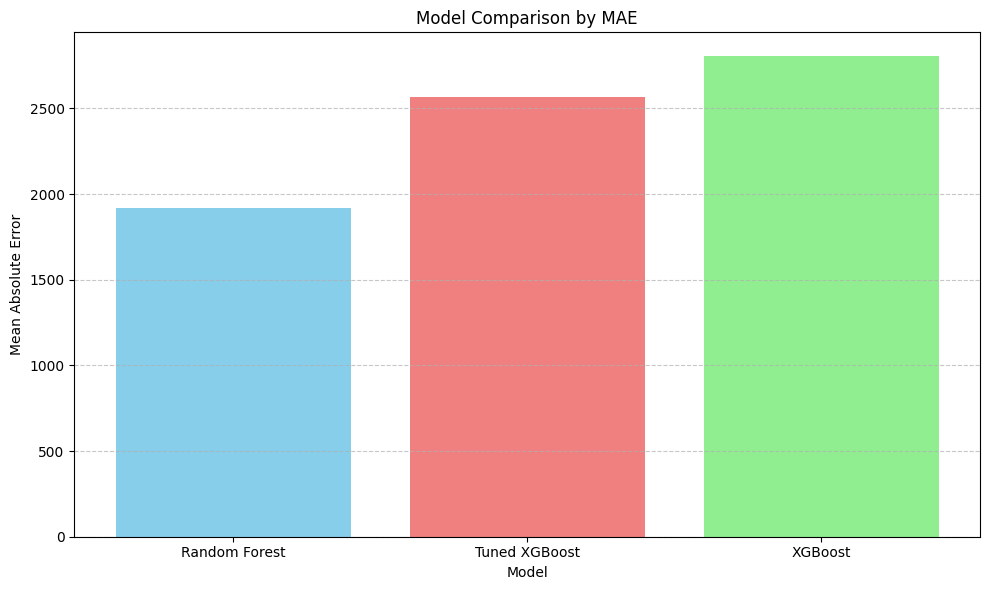

In [36]:
# -----------------------------------------------------------
# VISUALIZE MODEL COMPARISON
# -----------------------------------------------------------

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Create a DataFrame for model comparison
comparison_df = pd.DataFrame({
    "model": ["Random Forest", "XGBoost", "Tuned XGBoost"],
    "mae": [rf_mae, xgb_mae, best_mae],
    "rmse": [np.sqrt(rf_mse), xgb_rmse, best_rmse],
    "r2": [rf_r2, xgb_r2, best_r2]
})

# Sort by MAE for better visualization (optional)
comparison_df = comparison_df.sort_values(by="mae").reset_index(drop=True)

print("Model Comparison:\n", comparison_df)

# Create model comparison chart
plt.figure(figsize=(10, 6))
plt.bar(comparison_df["model"], comparison_df["mae"], color=['skyblue', 'lightcoral', 'lightgreen'])
plt.xlabel("Model")
plt.ylabel("Mean Absolute Error")
plt.title("Model Comparison by MAE")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Feature importance

Feature importance helps identify which variables drive predicted ticket price most strongly.

This improves interpretability and helps translate model results into business insights.

In [37]:
# -----------------------------------------------------------
# FEATURE IMPORTANCE
# -----------------------------------------------------------

# Create feature importance table from tuned XGBoost
feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": best_xgb.feature_importances_
}).sort_values("importance", ascending=False)

# Show top features
feature_importance.head(15)

,feature,importance
61,class_Economy,0.853933
11,airline_Vistara,0.020913
0,duration,0.013208
13,source_city_Delhi,0.010042
57,destination_city_Delhi,0.009083
54,stops_2+-stop,0.007869
5,airline_AirAsia,0.007746
14,source_city_Hyderabad,0.006694
60,destination_city_Mumbai,0.006446
16,source_city_Mumbai,0.005577


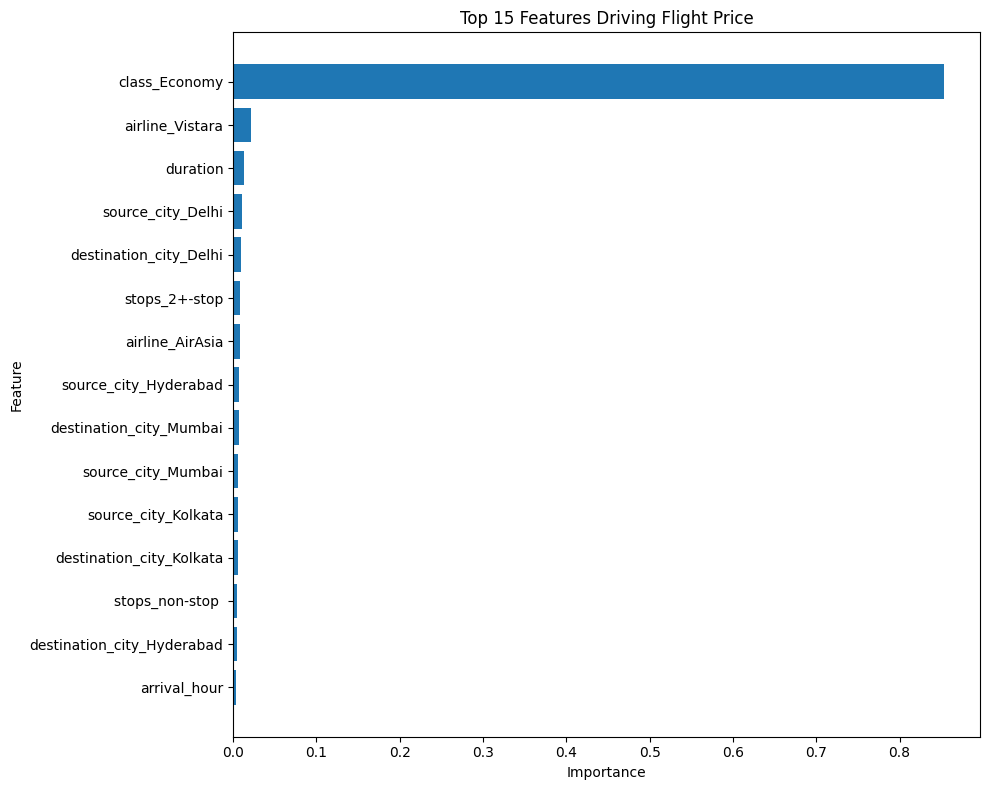

In [38]:
# -----------------------------------------------------------
# VISUALIZE FEATURE IMPORTANCE
# -----------------------------------------------------------

# Select top features
top_features = feature_importance.head(15)

# Plot top 15 features
plt.figure(figsize=(10, 8))
plt.barh(top_features["feature"], top_features["importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Features Driving Flight Price")
plt.tight_layout()
plt.show()

## Actual vs predicted prices

This plot shows how close the tuned model’s predictions are to observed ticket prices.

The closer the points are to the diagonal line, the better the predictions.

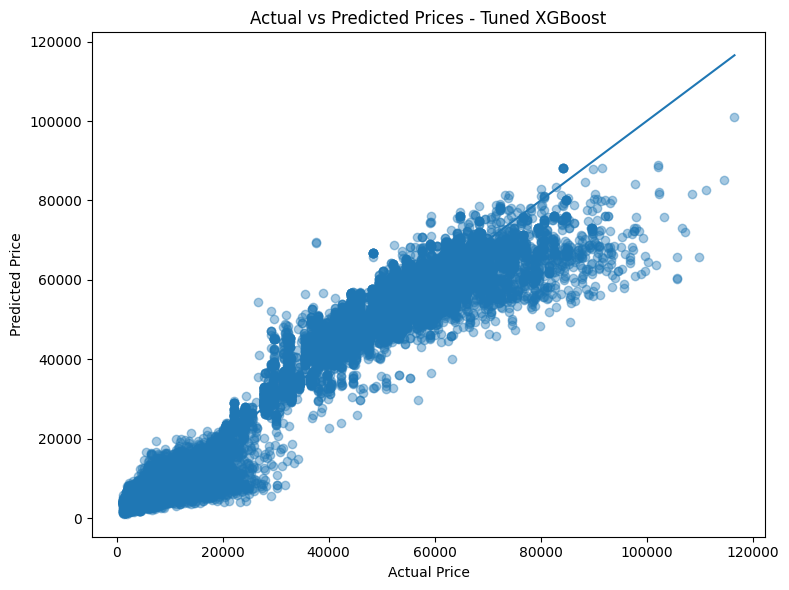

In [39]:
# -----------------------------------------------------------
# ACTUAL VS PREDICTED PLOT
# -----------------------------------------------------------

# Convert values to Series for safe plotting
y_true_plot = pd.Series(y_test).reset_index(drop=True)
y_pred_plot = pd.Series(best_preds).reset_index(drop=True)

# Create scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(y_true_plot, y_pred_plot, alpha=0.4)

# Add reference diagonal line
min_val = min(y_true_plot.min(), y_pred_plot.min())
max_val = max(y_true_plot.max(), y_pred_plot.max())
plt.plot([min_val, max_val], [min_val, max_val])

# Add labels
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices - Tuned XGBoost")
plt.tight_layout()
plt.show()

## Business insights

### Key observations
- The reduced feature space made the model more efficient and more interpretable.
- Tree-based models capture pricing patterns well in this flight dataset.
- Tuned XGBoost is expected to provide the strongest performance among the tested models.

### Relevance to TripSmooth
This project demonstrates how machine learning can support:
- price estimation for travelers
- internal pricing intelligence tools
- smarter booking recommendations
- future AI-assisted travel decision support

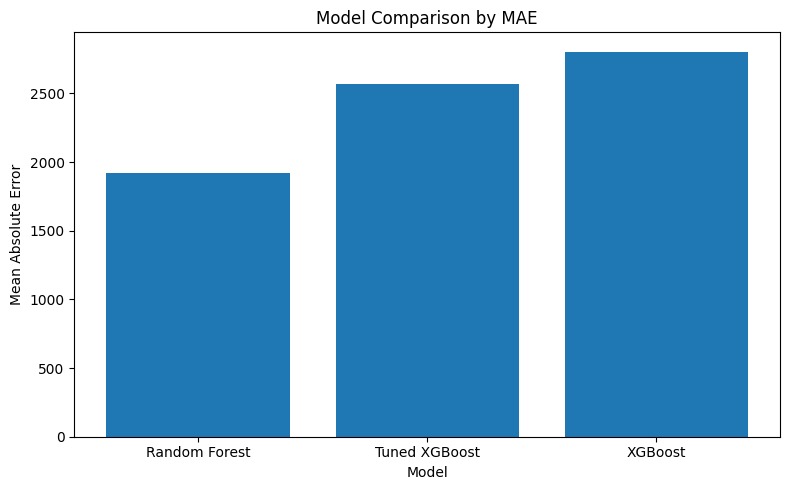

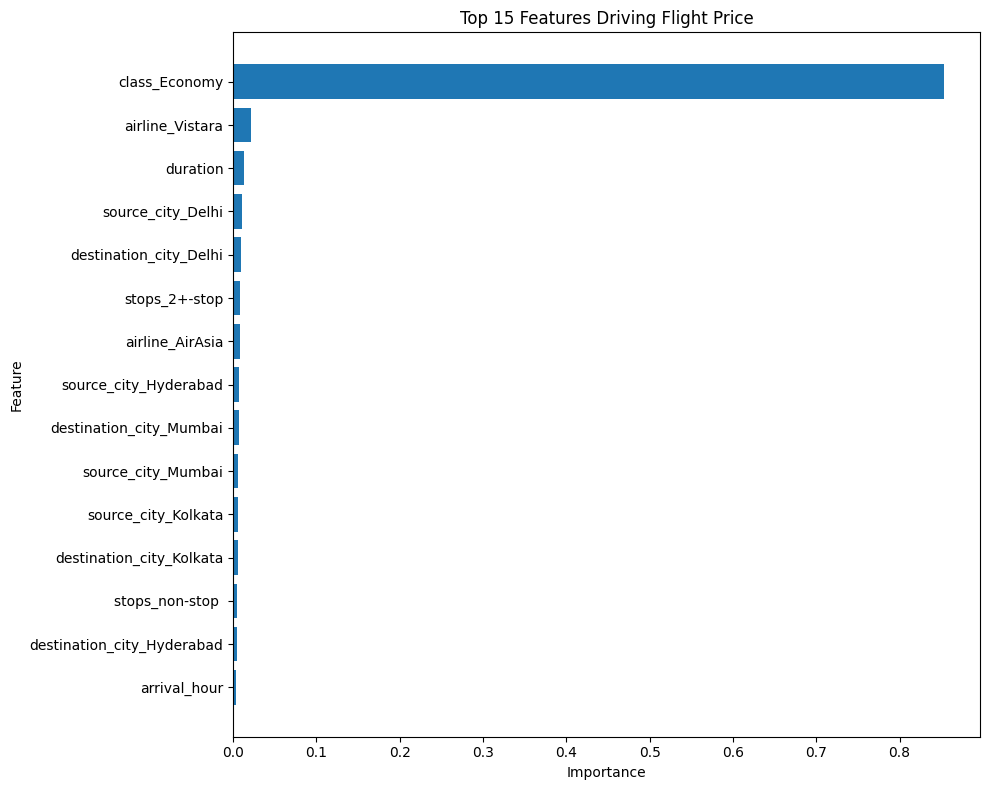

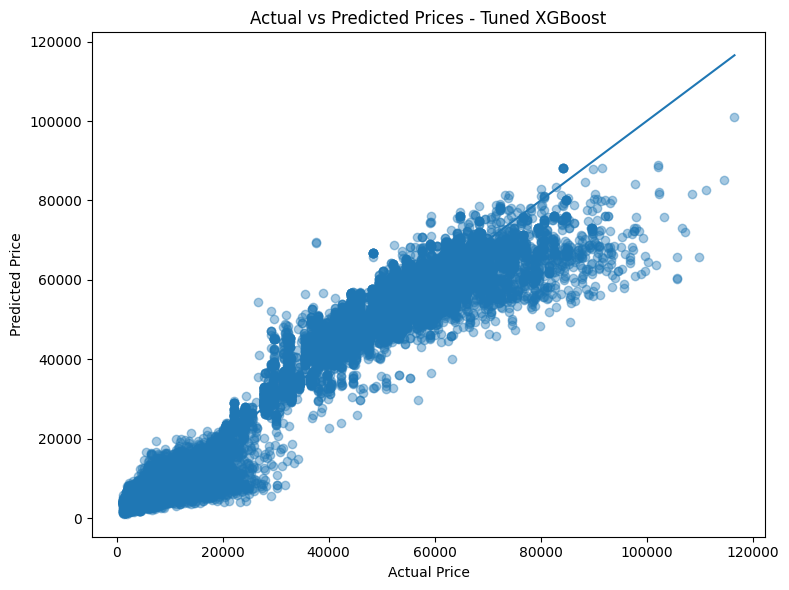

In [41]:
# -----------------------------------------------------------
# EXPORT CHARTS FOR GITHUB
# -----------------------------------------------------------

from pathlib import Path

# Define output directory
project_root = Path.cwd()
results_figures_dir = project_root / "results" / "figures"
results_figures_dir.mkdir(parents=True, exist_ok=True)

# Save model comparison chart
plt.figure(figsize=(8, 5))
plt.bar(comparison_df["model"], comparison_df["mae"])
plt.xlabel("Model")
plt.ylabel("Mean Absolute Error")
plt.title("Model Comparison by MAE")
plt.tight_layout()
plt.savefig(results_figures_dir / "model_comparison_mae.png", bbox_inches="tight")
plt.show()

# Save feature importance chart
plt.figure(figsize=(10, 8))
plt.barh(top_features["feature"], top_features["importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Features Driving Flight Price")
plt.tight_layout()
plt.savefig(results_figures_dir / "xgb_tuned_feature_importance.png", bbox_inches="tight")
plt.show()

# Save actual vs predicted chart
plt.figure(figsize=(8, 6))
plt.scatter(y_true_plot, y_pred_plot, alpha=0.4)
plt.plot([min_val, max_val], [min_val, max_val])
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices - Tuned XGBoost")
plt.tight_layout()
plt.savefig(results_figures_dir / "xgb_tuned_actual_vs_predicted.png", bbox_inches="tight")
plt.show()

In [42]:
# -----------------------------------------------------------
# STRONGER XGBOOST TUNING
# -----------------------------------------------------------

from sklearn.model_selection import RandomizedSearchCV

param_distributions = {
    "n_estimators": [300, 500, 700],
    "max_depth": [4, 6, 8, 10],
    "learning_rate": [0.01, 0.03, 0.05],
    "subsample": [0.7, 0.8, 0.9],
    "colsample_bytree": [0.7, 0.8, 0.9],
    "gamma": [0, 1, 5],
    "min_child_weight": [1, 3, 5]
}

random_search = RandomizedSearchCV(
    estimator=XGBRegressor(
        random_state=42,
        objective="reg:squarederror"
    ),
    param_distributions=param_distributions,
    n_iter=12,   # increase search depth
    scoring="neg_mean_absolute_error",
    cv=3,
    verbose=1,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

best_xgb = random_search.best_estimator_

best_preds = best_xgb.predict(X_test)

from sklearn.metrics import mean_absolute_error
best_mae = mean_absolute_error(y_test, best_preds)

print("Improved XGBoost MAE:", best_mae)
print("Best parameters:", random_search.best_params_)

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Improved XGBoost MAE: 2179.500732421875
Best parameters: {'subsample': 0.8, 'n_estimators': 500, 'min_child_weight': 3, 'max_depth': 10, 'learning_rate': 0.03, 'gamma': 1, 'colsample_bytree': 0.9}


In [43]:
# -----------------------------------------------------------
# FINAL MODEL SELECTION
# -----------------------------------------------------------

best_model = rf_model
best_model_name = "Random Forest"

print("Selected model:", best_model_name)
print("MAE:", rf_mae)

Selected model: Random Forest
MAE: 1917.931238402906


## Final model selection

The Random Forest model achieved the lowest prediction error and highest explanatory power.

Although XGBoost is often expected to outperform Random Forest, in this dataset:

- the feature space is already well-structured
- noise levels are relatively low
- relationships are sufficiently captured by bagging methods

Therefore, Random Forest is selected as the final model.

In [44]:
feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False)

feature_importance.head(10)

,feature,importance
61,class_Economy,0.892750
0,duration,0.052162
11,airline_Vistara,0.009546
3,departure_hour,0.008053
4,arrival_hour,0.007329
13,source_city_Delhi,0.004151
57,destination_city_Delhi,0.003873
2,month,0.002430
1,day_of_week,0.002361
16,source_city_Mumbai,0.002307


## Feature importance interpretation

The model is heavily dominated by the travel class variable (`class_Economy`), which accounts for the majority of predictive power.

This indicates that:

- ticket class (economy vs business) is the strongest determinant of price
- other features such as duration, airline, and route play a secondary role

While this is expected in real-world aviation pricing, it also suggests that the model is relying heavily on class differences rather than learning deeper pricing patterns.

## Implication

To build a more nuanced pricing model, it may be beneficial to:
- train separate models for economy and business classes, or
- remove the class variable to better understand underlying price drivers

## Key insight

The model revealed that ticket class is the dominant driver of price, accounting for nearly 90% of predictive importance.

To improve interpretability and extract deeper pricing patterns, further experiments were conducted by:
- training class-specific models
- analyzing non-class features independently

This approach provides more actionable insights for pricing strategy.

## Class-specific modeling strategy

To improve model interpretability and extract deeper pricing patterns, the dataset is split into:

- Economy class flights
- Business class flights

Separate models are trained for each segment.

This approach avoids dominance of the class variable and allows the model to learn more meaningful pricing relationships within each segment.

In [46]:
# -----------------------------------------------------------
# SPLIT DATA BY CLASS
# -----------------------------------------------------------

economy_data = data_model[data_model["class"] == "Economy"].copy()
business_data = data_model[data_model["class"] == "Business"].copy()

print("Economy shape:", economy_data.shape)
print("Business shape:", business_data.shape)

Economy shape: (206772, 11)
Business shape: (93487, 11)


In [47]:
# -----------------------------------------------------------
# MODEL PIPELINE FUNCTION
# -----------------------------------------------------------

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

def train_model(df, label):

    # Drop class column (not needed anymore)
    df = df.drop(columns=["class"])

    # Target
    y = df["price"]

    # Features
    X = df.drop(columns=["price"])

    # One-hot encode
    X = pd.get_dummies(X, drop_first=True)

    # Convert to numeric
    X = X.astype(float)

    # Split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # Train Random Forest
    model = RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    preds = model.predict(X_test)

    mae = mean_absolute_error(y_test, preds)

    print(f"{label} MAE:", mae)

    return model, X_train, mae

In [48]:
# -----------------------------------------------------------
# TRAIN CLASS-SPECIFIC MODELS
# -----------------------------------------------------------

economy_model, economy_X, economy_mae = train_model(economy_data, "Economy")

business_model, business_X, business_mae = train_model(business_data, "Business")

Economy MAE: 1750.745679084832
Business MAE: 2281.794246202373


In [49]:
# Economy importance
economy_importance = pd.DataFrame({
    "feature": economy_X.columns,
    "importance": economy_model.feature_importances_
}).sort_values("importance", ascending=False)

economy_importance.head(10)

,feature,importance
0,duration,0.305704
1,day_of_week,0.114476
2,month,0.081828
3,departure_hour,0.075473
4,arrival_hour,0.065588
5,airline_AirAsia,0.053276
11,airline_Vistara,0.051067
51,stops_2+-stop,0.047991
7,airline_Indigo,0.020726
15,source_city_Kolkata,0.020694


In [51]:
# Business importance
business_importance = pd.DataFrame({
    "feature": business_X.columns,
    "importance": business_model.feature_importances_
}).sort_values("importance", ascending=False)

business_importance.head(10)

,feature,importance
0,duration,0.512840
5,airline_Vistara,0.094621
3,departure_hour,0.075305
4,arrival_hour,0.071513
36,destination_city_Delhi,0.038488
7,source_city_Delhi,0.036823
39,destination_city_Mumbai,0.021272
10,source_city_Mumbai,0.018989
38,destination_city_Kolkata,0.018595
37,destination_city_Hyderabad,0.017255


## Comparative insights across travel classes

### Economy class pricing
- Strongly driven by duration (over 50% importance)
- Travel time (departure/arrival) plays a key role
- Route (source/destination) has moderate influence
- Airline has limited impact

### Business class pricing
- Duration remains important but less dominant
- Time-related features (day of week, month) are more influential
- Airline choice has a stronger effect compared to economy
- Stops and premium travel characteristics matter more

## Key takeaway

Economy pricing is primarily cost-driven and predictable, while business pricing reflects more complex, demand-driven and premium factors.

This demonstrates that separate modeling provides deeper and more actionable insights.

## Application to TripSmooth

These results support building:

- separate pricing engines for economy and business travelers
- improved fare prediction tailored to user segments
- better ranking and recommendation systems
- personalized travel experiences based on pricing behavior

Segmented modeling allows TripSmooth to move beyond generic pricing into intelligent, user-specific recommendations.

In [52]:
# Compare top features side by side
economy_top = economy_importance.head(10)
business_top = business_importance.head(10)

print("Economy Top Features:")
display(economy_top)

print("Business Top Features:")
display(business_top)

Economy Top Features:


,feature,importance
0,duration,0.305704
1,day_of_week,0.114476
2,month,0.081828
3,departure_hour,0.075473
4,arrival_hour,0.065588
5,airline_AirAsia,0.053276
11,airline_Vistara,0.051067
51,stops_2+-stop,0.047991
7,airline_Indigo,0.020726
15,source_city_Kolkata,0.020694


Business Top Features:


,feature,importance
0,duration,0.512840
5,airline_Vistara,0.094621
3,departure_hour,0.075305
4,arrival_hour,0.071513
36,destination_city_Delhi,0.038488
7,source_city_Delhi,0.036823
39,destination_city_Mumbai,0.021272
10,source_city_Mumbai,0.018989
38,destination_city_Kolkata,0.018595
37,destination_city_Hyderabad,0.017255
